# Import Library & Load Dataset

In [52]:
# Import Library

import pandas as pd 
import numpy as nm 
import matplotlib.pyplot as plt 
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Data Understanding

In [53]:
# Load Dataset

df = pd.read_csv("../data/raw/Sample-Superstore.csv")

In [54]:
# Cek ukuran dataset

df.shape

# dataset memiliki 9800 baris dan 18 kolom

(9800, 18)

In [55]:
# melihat data

df.head()

# dataset berisi informasi tentang transaksi, pelanggan, produk, lokasi, dan nilai penjualan


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [56]:
# Informasi dataset

df.info()

# sebagian besar kolom bertipe data object, kolom tanggal perlu dikonversi menjadi datetime

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [57]:
# statistik numerik

df.describe()

# sales memiliki rentang yang cukup besar dari 0.44 hingga 22638, 
# menunjukan adanya transaksi bernilai tinggi.

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


# Data Cleaning

In [58]:
# Missing Value

df.isnull().sum()


# terdapat missing value pada kolom postal code, tetapi jumlahnya relatif kecil (1.5% dari total data),
# bisa diubah menjadi 0 atau diabaikan tergantung analisis yang dilakukan.

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [59]:
# Duplikasi Data

df.duplicated().sum()

# tidak terdapat duplikasi data, sehingga tidak  perlu dilakukan penghapusan duplikasi data.

np.int64(0)

In [60]:
# merubah tipe data kolom Order Date dan Ship Date menjadi datetime

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format = "%d/%m/%Y")



# Feature Engineering

In [61]:
# Menambahkan kolom baru untuk analisis lebih lanjut

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Shipping Time"] = (df["Ship Date"]-df["Order Date"]).dt.days

# feature engineering ini akan memudahkan analisis berdasarkan waktu dan lama pengiriman barang.

# Univariate Analysis

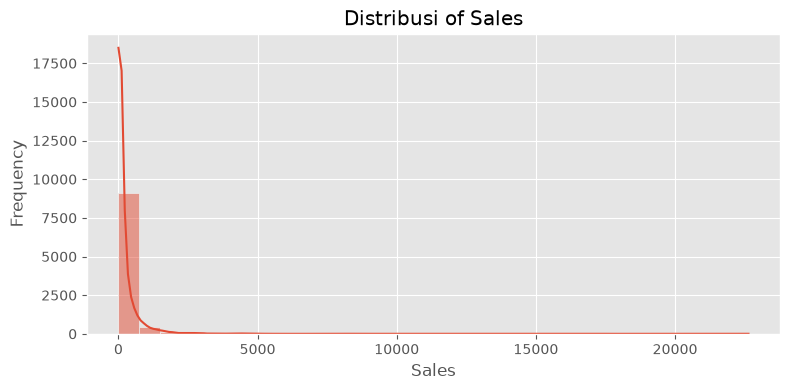

In [62]:
# Distribusi sales

plt.figure(figsize=(8,4))

sns.histplot(
    data = df,
    x = "Sales",
    bins=30,
    kde=True
)

plt.title("Distribusi of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../images/Sales_Distribution.png",dpi=300)

plt.show()


# distribusi sales cenderung skewed ke kanan, yang menunjukan sebagian besar trabsaksi bernilai kecil, 
# sementara hanya sedikit transaksi bernilai besar.

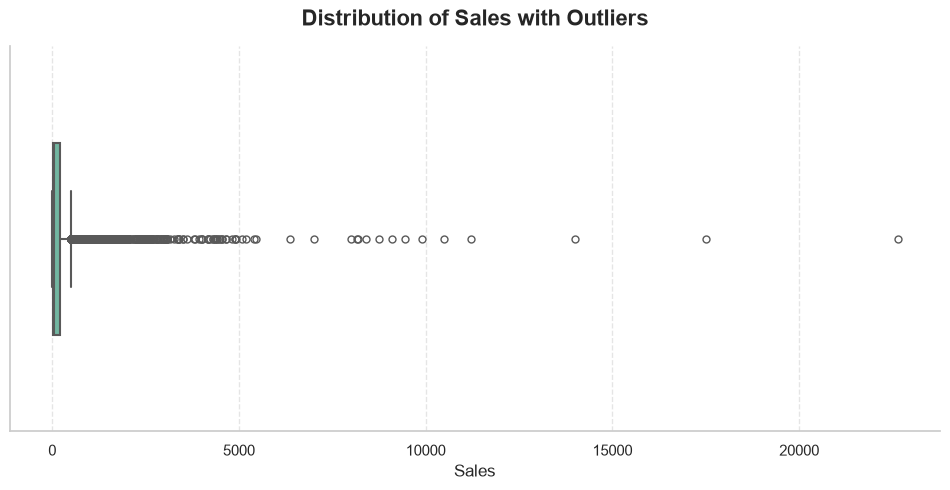

In [77]:
# boxplot untuk mendeteksi outlier pada kolom sales

sns.set_theme(style="whitegrid", palette="Set2")

plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["Sales"],
    linewidth=1.5,
    width=0.5,
    fliersize=5
    )

plt.title(
    "Distribution of Sales with Outliers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sales", fontsize=12)
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.5)

sns.despine()

plt.savefig("../images/Sales_Boxplot.png",dpi=300, bbox_inches="tight")

plt.show()
# Terdapat beberapa transaksi dengan nilai penjualan yang jauh lebih tinggi dibanding mayoritas transaksi (outlier).

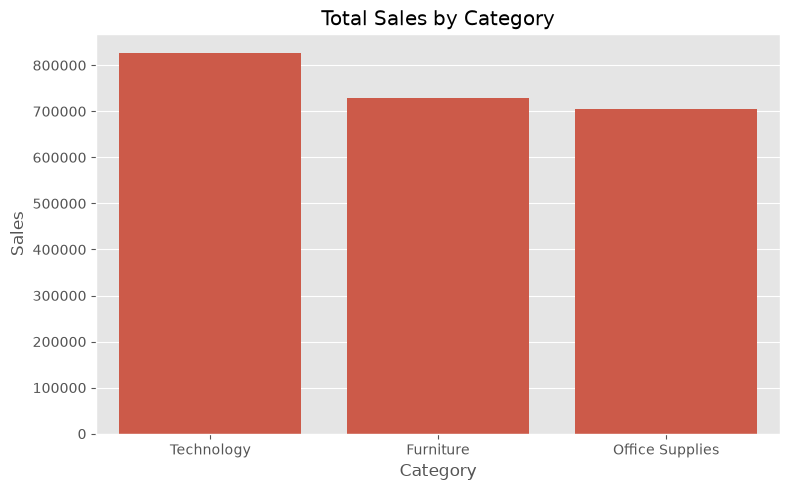

In [64]:
# Category analysis

category_sales = (
    df.groupby("Category")["Sales"]
    .sum().
    sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../images/category_sales.png",dpi=300)

plt.show()


# kategori dengan total penjualan tertinggi menunjukan kontribusi terbesar terhadap pendapatan perusahaan,
# sementara kategori dengan total penjualan terendah mungkin memerlukan strategi pemasaran yang lebih baik untuk meningkatkan penjualan.


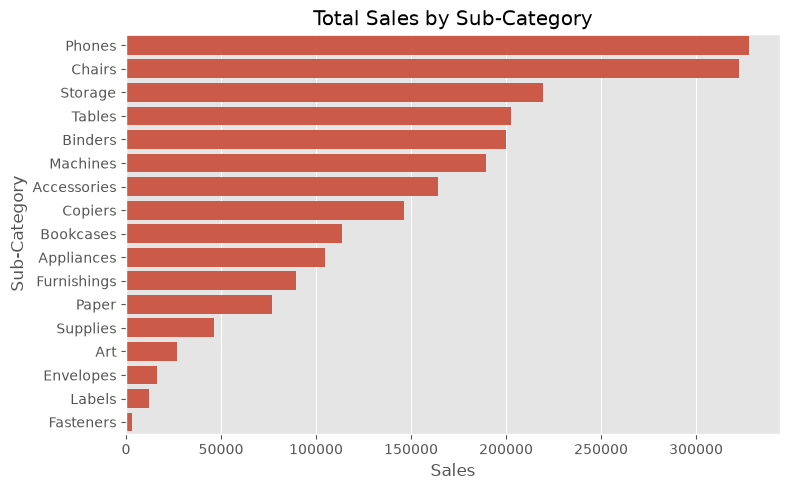

In [73]:
# Sub-category analysis

sub_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum().
    sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=sub_sales.values,
    y=sub_sales.index
)

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()

plt.savefig("../images/sub_category_sales.png",dpi=300)

plt.show()




# beberapa sub-kategori memiliki kontribusi yang jauh lebih besar di banding sub-kategori lainnya.


<Axes: xlabel='Region'>

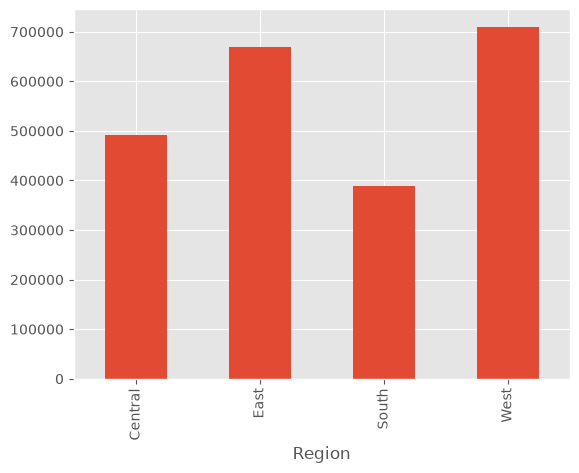

In [66]:
# Region analysis

region = df.groupby("Region")["Sales"].sum()
region.plot(kind="bar")


# Region dengan penjualan tertinggi dapat dijadikan acuan dalam penyusunan strategi pemasaran, 
# sedangkan region dengan penjualan rendah memerlukan evaluasi lebih lanjut..

<Axes: xlabel='Segment'>

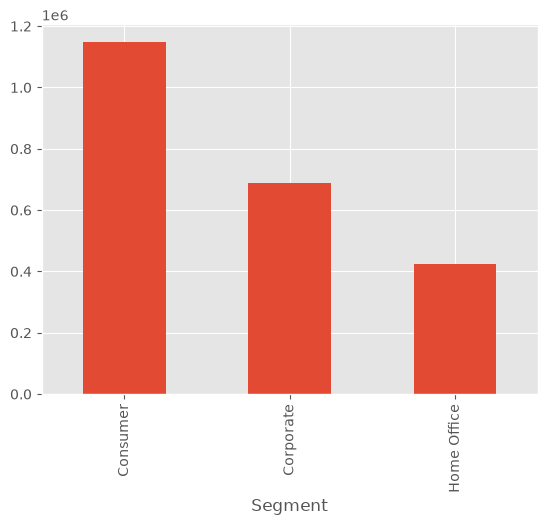

In [67]:
# Segment analysis

segment = df.groupby("Segment")["Sales"].sum()
segment.plot(kind="bar")


# Analisis ini membantu mengidentifikasi segmen pelanggan yang memberikan kontribusi penjualan terbesar.